In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Bank_Personal_Loan_Modelling.xlsx to Bank_Personal_Loan_Modelling.xlsx


In [ ]:
import os
print(os.listdir())

['.config', 'Bank_Personal_Loan_Modelling.xlsx', 'sample_data']


In [ ]:
real_df = pd.read_excel("Bank_Personal_Loan_Modelling.xlsx", sheet_name="Data")

print(real_df.shape)
real_df.head()

(5000, 14)


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [ ]:
real_df = real_df.sample(2000, random_state=42)
print(real_df.shape)

(2000, 14)


In [ ]:
real_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 1501 to 3209
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  2000 non-null   int64  
 1   Age                 2000 non-null   int64  
 2   Experience          2000 non-null   int64  
 3   Income              2000 non-null   int64  
 4   ZIP Code            2000 non-null   int64  
 5   Family              2000 non-null   int64  
 6   CCAvg               2000 non-null   float64
 7   Education           2000 non-null   int64  
 8   Mortgage            2000 non-null   int64  
 9   Personal Loan       2000 non-null   int64  
 10  Securities Account  2000 non-null   int64  
 11  CD Account          2000 non-null   int64  
 12  Online              2000 non-null   int64  
 13  CreditCard          2000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 234.4 KB


In [ ]:
real_df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2451.996500,45.908000,20.67800,74.033000,93146.811000,2.420500,1.949183,1.877000,54.267500,0.100500,0.102500,0.059500,0.593500,0.295000
std,1449.966841,11.546696,11.56184,46.838006,1738.479763,1.143824,1.757812,0.843935,97.180898,0.300741,0.303381,0.236617,0.491303,0.456157
min,1.000000,23.000000,-3.00000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1204.000000,36.000000,11.00000,38.000000,91787.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2409.000000,46.000000,21.00000,63.000000,93407.000000,2.000000,1.550000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,3705.250000,56.000000,30.00000,101.000000,94588.500000,3.000000,2.600000,3.000000,99.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,5000.000000,67.000000,43.00000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
real_df.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIP Code,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal Loan,0


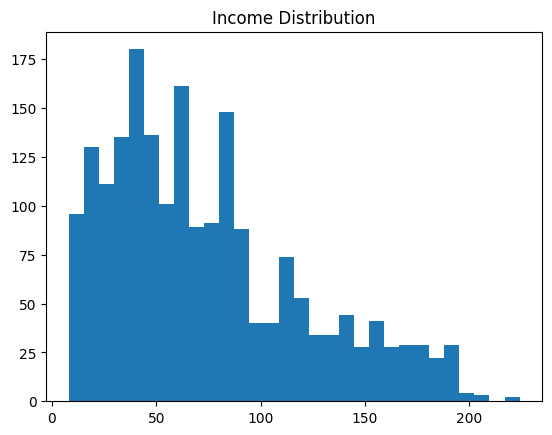

In [ ]:
import matplotlib.pyplot as plt

plt.hist(real_df["Income"], bins=30)
plt.title("Income Distribution")
plt.show()

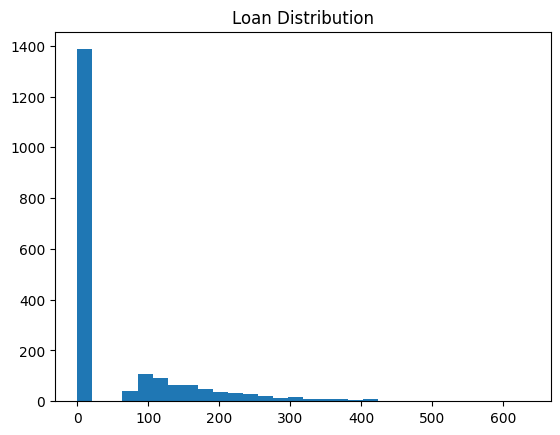

In [ ]:
plt.hist(real_df["Mortgage"], bins=30)
plt.title("Loan Distribution")
plt.show()

In [ ]:
real_df.corr()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,1.000000,-0.028647,-0.028857,-0.003212,-0.009618,-0.032062,-0.015437,0.019243,0.008599,-0.012649,-0.026732,-0.023146,0.003973,-0.006054
Age,-0.028647,1.000000,0.994162,-0.079396,-0.036659,-0.024265,-0.079359,0.058490,-0.012819,-0.032198,-0.004733,0.011709,0.025414,0.040012
Experience,-0.028857,0.994162,1.000000,-0.071555,-0.035874,-0.031782,-0.077319,0.029110,-0.012703,-0.033849,-0.008128,0.012858,0.025294,0.037559
Income,-0.003212,-0.079396,-0.071555,1.000000,-0.004969,-0.151890,0.652295,-0.184503,0.156784,0.511908,0.000994,0.196805,-0.003612,0.028694
ZIP Code,-0.009618,-0.036659,-0.035874,-0.004969,1.000000,-0.006870,0.000135,-0.039644,-0.010649,0.021641,0.019739,0.036288,0.015560,0.034330
Family,-0.032062,-0.024265,-0.031782,-0.151890,-0.006870,1.000000,-0.116874,0.065526,-0.016093,0.044324,0.012682,-0.001921,0.003442,0.024837
CCAvg,-0.015437,-0.079359,-0.077319,0.652295,0.000135,-0.116874,1.000000,-0.154585,0.037205,0.357047,0.016729,0.149175,-0.010734,0.013506
Education,0.019243,0.058490,0.029110,-0.184503,-0.039644,0.065526,-0.154585,1.000000,-0.045052,0.151221,0.002374,0.031657,-0.016890,-0.013553
Mortgage,0.008599,-0.012819,-0.012703,0.156784,-0.010649,-0.016093,0.037205,-0.045052,1.000000,0.098201,0.004872,0.075254,0.016245,-0.001217
Personal Loan,-0.012649,-0.032198,-0.033849,0.511908,0.021641,0.044324,0.357047,0.151221,0.098201,1.000000,0.024111,0.337719,-0.011151,0.013510


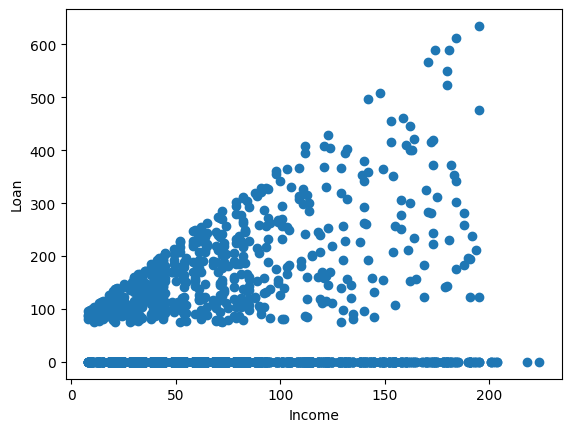

In [ ]:
plt.scatter(real_df["Income"], real_df["Mortgage"])
plt.xlabel("Income")
plt.ylabel("Loan")
plt.show()